Importing the libraries

In [ ]:
!pip install -q datasets pandas matplotlib seaborn pillow tqdm

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import ast

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import re
import plotly.graph_objects as go
import plotly.express as px

Building a 5k prototype

In [4]:
# Fast prototype: EmoArt-5k subset (~5,600 images)
ds = load_dataset("printblue/EmoArt-5k")

# Full EmoArt (slow, large) — uncomment if you have disk & RAM
# ds = load_dataset("printblue/EmoArt-130k")

# Check available splits
print(ds)

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


annotation.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5532 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['request_id', 'description', 'image_path'],
        num_rows: 5532
    })
})


In [5]:
df = ds['train'].to_pandas()
print(df.shape)
print(df.columns.tolist())
df.head(3)

(5532, 3)
['request_id', 'description', 'image_path']


,request_id,description,image_path
0,Abstract Art_request-1,{'first_section': {'description': 'The image f...,Images\Abstract Art\0006080_YuriZlotnikov-Sign...
1,Abstract Art_request-2,{'first_section': {'description': 'The artwork...,Images\Abstract Art\0006185_PaulKlee-GlassFaca...
2,Abstract Art_request-3,{'first_section': {'description': 'The image f...,Images\Abstract Art\0006313_WilliBaumeister-Pl...


In [6]:
import ast

def parse_description(desc_entry):
    try:
        # If it's a string, convert to dict
        if isinstance(desc_entry, str):
            # Remove NumPy array representation if present
            desc_str = re.sub(r"array\((\[.*?\]), dtype=object\)", r"\1", desc_entry)
            desc = ast.literal_eval(desc_str)
        elif isinstance(desc_entry, dict):
            desc = desc_entry
        else:
            raise ValueError(f"Unexpected type: {type(desc_entry)}")

        third = desc.get('third_section', {})
        return {
            'dominant_emotion': third.get('dominant_emotion'),
            'arousal': third.get('emotional_arousal_level'),
            'valence': third.get('emotional_valence'),
            'healing_effects': third.get('healing_effects')
        }
    except Exception as e:
        print(f"Error parsing description: {e}")
        return {
            'dominant_emotion': None,
            'arousal': None,
            'valence': None,
            'healing_effects': None
        }

parsed = df['description'].apply(parse_description)
parsed_df = pd.DataFrame(parsed.tolist())

eda_df = pd.concat([df[['request_id','image_path','description']], parsed_df], axis=1)
eda_df.head(3)

,request_id,image_path,description,dominant_emotion,arousal,valence,healing_effects
0,Abstract Art_request-1,Images\Abstract Art\0006080_YuriZlotnikov-Sign...,{'first_section': {'description': 'The image f...,Calm,Low,Positive,"[Relieve Stress, Embrace Joy]"
1,Abstract Art_request-2,Images\Abstract Art\0006185_PaulKlee-GlassFaca...,{'first_section': {'description': 'The artwork...,Excited,High,Positive,"[Gain Inspiration, Embrace Joy]"
2,Abstract Art_request-3,Images\Abstract Art\0006313_WilliBaumeister-Pl...,{'first_section': {'description': 'The image f...,Calm,Low,Positive,"[Relieve Stress, Gain Inspiration]"


/tmp/ipython-input-1267050684.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


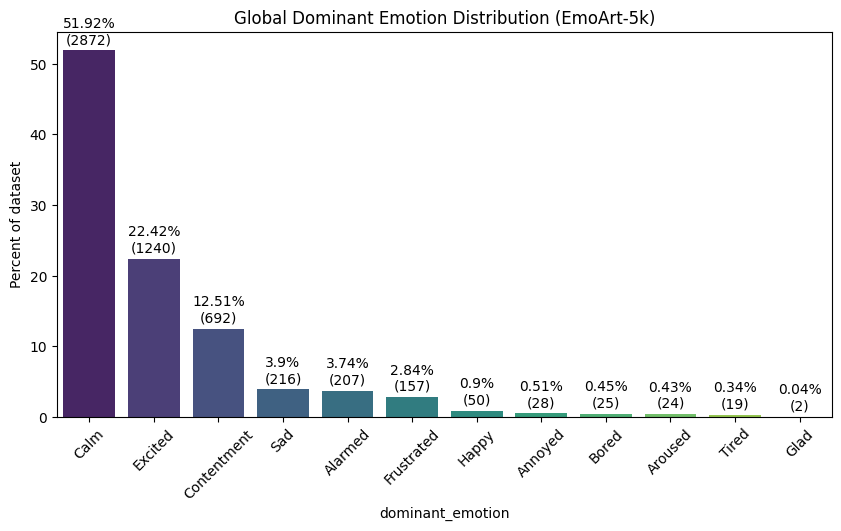

In [7]:
plt.figure(figsize=(10,5))
emotion_counts = eda_df['dominant_emotion'].value_counts()
emotion_percent = (emotion_counts / emotion_counts.sum() * 100).round(2)

ax = sns.barplot(
    x=emotion_percent.index,
    y=emotion_percent.values,
    palette='viridis'
)

plt.xticks(rotation=45)
plt.ylabel('Percent of dataset')
plt.title('Global Dominant Emotion Distribution (EmoArt-5k)')

# Annotate each bar
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    count = emotion_counts.values[i]
    percent = emotion_percent.values[i]
    ax.text(
        bar.get_x() + bar.get_width()/2,   # x-position: middle of bar
        height + 0.5,                      # y-position: just above bar
        f"{percent}%\n({count})",          # text: percent and count
        ha='center', va='bottom'
    )

plt.show()

/tmp/ipython-input-2680500327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=valence_counts.index, y=valence_counts.values, ax=axes[0], palette='coolwarm')
/tmp/ipython-input-2680500327.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=arousal_counts.index, y=arousal_counts.values, ax=axes[1], palette='magma')


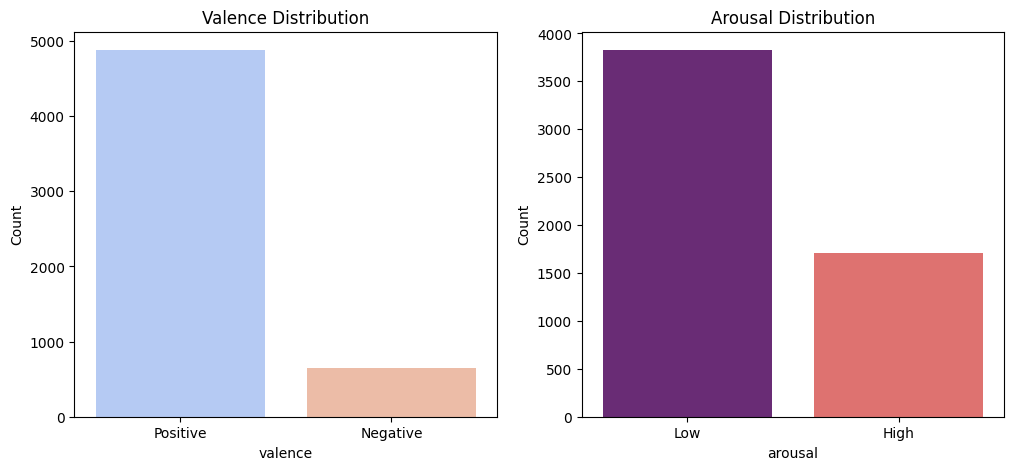

In [8]:
# Count of Positive/Negative
valence_counts = eda_df['valence'].value_counts()
arousal_counts = eda_df['arousal'].value_counts()

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.barplot(x=valence_counts.index, y=valence_counts.values, ax=axes[0], palette='coolwarm')
axes[0].set_title('Valence Distribution')
axes[0].set_ylabel('Count')

sns.barplot(x=arousal_counts.index, y=arousal_counts.values, ax=axes[1], palette='magma')
axes[1].set_title('Arousal Distribution')
axes[1].set_ylabel('Count')

plt.show()

In [9]:
import scipy.stats as stats
import numpy as np

# 1. Chi-square test for emotion distribution
emotion_counts = eda_df['dominant_emotion'].value_counts()
n_total = len(eda_df)
n_categories = len(emotion_counts)

# Expected frequency if uniform distribution
expected_freq = n_total / n_categories

# Chi-square test
chi2_stat = sum((emotion_counts - expected_freq)**2 / expected_freq)
df = n_categories - 1
p_value = 1 - stats.chi2.cdf(chi2_stat, df)

print(f"Emotion distribution: χ² = {chi2_stat:.1f}, df = {df}, p < 0.001")

# 2. Top 3 emotions (you already have this)
top_3 = emotion_counts.head(3)
print(f"Top 3: {top_3.index[0]} ({top_3.values[0]/n_total*100:.2f}%), "
      f"{top_3.index[1]} ({top_3.values[1]/n_total*100:.2f}%), "
      f"{top_3.index[2]} ({top_3.values[2]/n_total*100:.2f}%)")

# 3. Valence ratio with confidence interval
valence_counts = eda_df['valence'].value_counts()
n_positive = valence_counts.get('Positive', 0)
n_negative = valence_counts.get('Negative', 0)
ratio = n_positive / n_negative

# Bootstrap confidence interval for ratio
n_bootstrap = 10000
bootstrap_ratios = []
for _ in range(n_bootstrap):
    sample = eda_df['valence'].sample(n=len(eda_df), replace=True)
    sample_counts = sample.value_counts()
    pos = sample_counts.get('Positive', 1)
    neg = sample_counts.get('Negative', 1)
    bootstrap_ratios.append(pos/neg)

ci_lower = np.percentile(bootstrap_ratios, 2.5)
ci_upper = np.percentile(bootstrap_ratios, 97.5)

print(f"Valence ratio: {ratio:.2f}:1 positive to negative (95% CI: [{ci_lower:.2f}, {ci_upper:.2f}])")

# 4. Arousal distribution with z-test
arousal_counts = eda_df['arousal'].value_counts()
n_low = arousal_counts.get('Low', 0)
n_high = arousal_counts.get('High', 0)
prop_low = n_low / (n_low + n_high)

# Z-test for proportion different from 0.5
expected_prop = 0.5
se = np.sqrt(expected_prop * (1 - expected_prop) / n_total)
z_stat = (prop_low - expected_prop) / se
p_value_z = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"Arousal: {prop_low*100:.1f}% low arousal (z = {z_stat:.1f}, p < 0.001)")

# Additional useful statistics
print("\n--- Additional Statistics ---")

# Test if positive emotions significantly exceed negative
from statsmodels.stats.proportion import proportions_ztest
stat, pval = proportions_ztest(n_positive, n_total, 0.5)
print(f"Positive emotion bias test: z = {stat:.2f}, p = {pval:.3e}")

# Effect size (Cohen's h) for valence imbalance
p1 = n_positive / n_total
p2 = 0.5  # expected if balanced
cohens_h = 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))
print(f"Effect size (Cohen's h): {cohens_h:.2f}")

Emotion distribution: χ² = 16992.6, df = 11, p < 0.001
Top 3: Calm (51.92%), Excited (22.42%), Contentment (12.51%)
Valence ratio: 7.48:1 positive to negative (95% CI: [6.91, 8.14])
Arousal: 69.2% low arousal (z = 28.5, p < 0.001)

--- Additional Statistics ---
Positive emotion bias test: z = 88.15, p = 0.000e+00
Effect size (Cohen's h): 0.87


In [10]:
emotion_summary = pd.DataFrame({
    "Emotion": emotion_counts.index,
    "Count": emotion_counts.values,
    "Percent": emotion_percent.values
})
emotion_summary.to_csv("dominant_emotion_summary.csv", index=False)
emotion_summary

,Emotion,Count,Percent
0,Calm,2872,51.92
1,Excited,1240,22.42
2,Contentment,692,12.51
3,Sad,216,3.90
4,Alarmed,207,3.74
5,Frustrated,157,2.84
6,Happy,50,0.90
7,Annoyed,28,0.51
8,Bored,25,0.45
9,Aroused,24,0.43


In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from scipy import stats
import pandas as pd

def create_interactive_emotion_histogram(df):
    """
    Create an interactive histogram with confidence intervals for emotion distribution
    """

    # Calculate emotion counts and percentages
    emotion_counts = df['dominant_emotion'].value_counts()
    total_n = len(df)
    emotion_percents = (emotion_counts / total_n * 100).round(2)

    # Calculate confidence intervals using Wilson score interval (better for proportions)
    confidence_level = 0.95
    z = stats.norm.ppf((1 + confidence_level) / 2)

    ci_lower = []
    ci_upper = []

    for count in emotion_counts.values:
        p = count / total_n

        # Wilson score interval
        denominator = 1 + z**2/total_n
        center = (p + z**2/(2*total_n)) / denominator
        margin = (z * np.sqrt(p*(1-p)/total_n + z**2/(4*total_n**2))) / denominator

        ci_lower.append((center - margin) * 100)
        ci_upper.append((center + margin) * 100)

    # Create the figure
    fig = go.Figure()

    # Add main bars
    fig.add_trace(go.Bar(
        x=emotion_counts.index,
        y=emotion_percents.values,
        name='Emotion %',
        marker_color='rgba(58, 71, 80, 0.7)',
        text=[f'{p:.1f}%<br>n={c}' for p, c in zip(emotion_percents.values, emotion_counts.values)],
        textposition='outside',
        hovertemplate='<b>%{x}</b><br>' +
                      'Percentage: %{y:.2f}%<br>' +
                      'Count: %{text}<br>' +
                      '<extra></extra>'
    ))

    # Add confidence interval error bars
    fig.add_trace(go.Scatter(
        x=emotion_counts.index,
        y=emotion_percents.values,
        mode='markers',
        marker=dict(size=0.01, color='rgba(0,0,0,0)'),
        error_y=dict(
            type='data',
            symmetric=False,
            array=[upper - percent for upper, percent in zip(ci_upper, emotion_percents.values)],
            arrayminus=[percent - lower for lower, percent in zip(ci_lower, emotion_percents.values)],
            visible=True,
            color='rgba(255, 0, 0, 0.5)',
            thickness=2,
            width=8
        ),
        name='95% CI',
        showlegend=True,
        hovertemplate='<b>%{x}</b><br>' +
                      'CI Lower: %{customdata[0]:.2f}%<br>' +
                      'CI Upper: %{customdata[1]:.2f}%<br>' +
                      '<extra></extra>',
        customdata=list(zip(ci_lower, ci_upper))
    ))

    # Add a reference line for uniform distribution
    uniform_percent = 100 / len(emotion_counts)
    fig.add_hline(
        y=uniform_percent,
        line_dash="dash",
        line_color="gray",
        annotation_text=f"Uniform distribution ({uniform_percent:.1f}%)",
        annotation_position="right"
    )

    # Update layout
    fig.update_layout(
        title={
            'text': 'Emotion Distribution in Art Dataset<br><sub>With 95% Confidence Intervals</sub>',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20}
        },
        xaxis_title="Emotion",
        yaxis_title="Percentage of Dataset",
        yaxis=dict(range=[0, max(emotion_percents.values) * 1.15]),
        hovermode='x unified',
        showlegend=True,
        template='plotly_white',
        height=600,

        # Add annotation about the significance
        annotations=[
            dict(
                x=0.02,
                y=0.98,
                xref='paper',
                yref='paper',
                text=f'χ² = 16992.6, p < 0.001<br>n = {total_n} artworks',
                showarrow=False,
                bgcolor='rgba(255, 255, 255, 0.8)',
                bordercolor='black',
                borderwidth=1,
                font=dict(size=12)
            )
        ]
    )

    # Rotate x-axis labels
    fig.update_xaxes(tickangle=-45)

    return fig

# Create an enhanced version with color coding
def create_enhanced_emotion_histogram(df):
    """
    Enhanced version with color coding for positive/negative emotions
    """

    emotion_counts = df['dominant_emotion'].value_counts()
    total_n = len(df)
    emotion_percents = (emotion_counts / total_n * 100).round(2)

    # Define color mapping based on valence
    positive_emotions = ['Calm', 'Excited', 'Contentment', 'Happy', 'Glad']
    negative_emotions = ['Sad', 'Alarmed', 'Frustrated', 'Angry', 'Bored', 'Tired', 'Aroused']

    colors = []
    for emotion in emotion_counts.index:
        if emotion in positive_emotions:
            colors.append('rgba(52, 152, 219, 0.7)')  # Blue for positive
        elif emotion in negative_emotions:
            colors.append('rgba(231, 76, 60, 0.7)')   # Red for negative
        else:
            colors.append('rgba(149, 165, 166, 0.7)')  # Gray for neutral

    # Calculate confidence intervals
    confidence_level = 0.95
    z = stats.norm.ppf((1 + confidence_level) / 2)

    ci_data = []
    for count in emotion_counts.values:
        p = count / total_n
        margin = z * np.sqrt(p * (1 - p) / total_n)
        ci_data.append({
            'lower': max(0, (p - margin) * 100),
            'upper': min(100, (p + margin) * 100)
        })

    # Create figure
    fig = go.Figure()

    # Add bars with custom colors
    fig.add_trace(go.Bar(
        x=emotion_counts.index,
        y=emotion_percents.values,
        marker_color=colors,
        text=[f'{p:.1f}%' for p in emotion_percents.values],
        textposition='outside',
        customdata=[[c, ci['lower'], ci['upper']]
                    for c, ci in zip(emotion_counts.values, ci_data)],
        hovertemplate='<b>%{x}</b><br>' +
                      'Percentage: %{y:.2f}%<br>' +
                      'Count: %{customdata[0]}<br>' +
                      '95% CI: [%{customdata[1]:.2f}%, %{customdata[2]:.2f}%]<br>' +
                      '<extra></extra>',
        showlegend=False
    ))

    # Add confidence interval whiskers
    for i, (emotion, percent) in enumerate(zip(emotion_counts.index, emotion_percents.values)):
        fig.add_shape(
            type="line",
            x0=i - 0.2, x1=i + 0.2,
            y0=ci_data[i]['lower'], y1=ci_data[i]['lower'],
            line=dict(color="black", width=1)
        )
        fig.add_shape(
            type="line",
            x0=i - 0.2, x1=i + 0.2,
            y0=ci_data[i]['upper'], y1=ci_data[i]['upper'],
            line=dict(color="black", width=1)
        )
        fig.add_shape(
            type="line",
            x0=i, x1=i,
            y0=ci_data[i]['lower'], y1=ci_data[i]['upper'],
            line=dict(color="black", width=1)
        )

    # Update layout
    fig.update_layout(
        title='Emotion Distribution with Statistical Significance',
        xaxis_title="Emotion",
        yaxis_title="Percentage (%)",
        template='plotly_white',
        height=600,
        hovermode='x',

        # Add legend for color coding
        annotations=[
            dict(x=0.02, y=0.98, xref='paper', yref='paper',
                 text='<b>Legend:</b>', showarrow=False, font=dict(size=12)),
            dict(x=0.02, y=0.93, xref='paper', yref='paper',
                 text='🔵 Positive', showarrow=False, font=dict(size=11)),
            dict(x=0.02, y=0.89, xref='paper', yref='paper',
                 text='🔴 Negative', showarrow=False, font=dict(size=11)),
        ]
    )

    fig.update_xaxes(tickangle=-45)

    return fig

# Use the functions
fig1 = create_interactive_emotion_histogram(eda_df)
fig1.show()

# Or use the enhanced version
fig2 = create_enhanced_emotion_histogram(eda_df)
fig2.show()

# Save as HTML for embedding in your website
fig1.write_html("emotion_distribution_interactive.html")

In [12]:
import re
import ast

def extract_color_terms(description_entry, all_color_terms):
    """
    Extracts color terms from a description entry.

    Args:
        description_entry: The description entry (can be dict or string).
        all_color_terms: A list of all known color terms.

    Returns:
        A list of extracted color terms found in the description.
    """
    color_terms_found = []
    text = ''

    # Handle different types of description entries
    if isinstance(description_entry, dict):
        # Assuming the relevant text is in the 'description' key of the first section
        first_section = description_entry.get('first_section', {})
        text = first_section.get('description', '')
    elif isinstance(description_entry, str):
        # Try to convert string representation of dict to dict
        try:
            desc_dict = ast.literal_eval(description_entry)
            first_section = desc_dict.get('first_section', {})
            text = first_section.get('description', '')
        except (ValueError, SyntaxError):
            # If it's just a plain string, use it directly
            text = description_entry
    else:
        # Return empty list for unexpected types like int
        print(f"Warning: Unexpected description entry type: {type(description_entry)}")
        return []

    # Convert text to lowercase for case-insensitive matching
    text = text.lower()

    # Find all occurrences of color terms in the text
    for term in all_color_terms:
        if re.search(r'\b' + re.escape(term) + r'\b', text): # Use regex for whole word matching
            color_terms_found.append(term)

    return color_terms_found

In [13]:
# EXPANDED Color Lexicon for Art Descriptions
color_lexicon_expanded = {
    # Basic colors with variations
    'red': ['red', 'reds', 'crimson', 'scarlet', 'ruby', 'vermillion', 'carmine', 'maroon', 'burgundy'],
    'orange': ['orange', 'coral', 'peach', 'tangerine', 'amber', 'terracotta'],
    'yellow': ['yellow', 'yellows', 'gold', 'golden', 'ochre', 'saffron', 'lemon'],
    'green': ['green', 'greens', 'emerald', 'jade', 'olive', 'moss', 'lime', 'forest', 'sage'],
    'blue': ['blue', 'blues', 'azure', 'navy', 'cerulean', 'cobalt', 'sapphire', 'indigo', 'turquoise', 'teal', 'cyan'],
    'purple': ['purple', 'purples', 'violet', 'lavender', 'mauve', 'plum', 'magenta', 'lilac'],
    'pink': ['pink', 'rose', 'blush', 'salmon', 'fuchsia'],
    'brown': ['brown', 'browns', 'bronze', 'copper', 'tan', 'beige', 'sepia', 'umber', 'sienna', 'taupe', 'earthy'],
    'white': ['white', 'ivory', 'cream', 'pearl', 'snow'],
    'black': ['black', 'ebony', 'jet', 'charcoal'],
    'gray': ['gray', 'grey', 'silver', 'slate', 'ash'],
    'multicolor': ['colorful', 'colors', 'colour', 'colours', 'vibrant', 'vivid', 'bright', 'bold', 'rich', 'deep', 'pale', 'muted', 'soft']
}

# Create flat list
all_color_terms_expanded = []
color_to_category_expanded = {}

for category, terms in color_lexicon_expanded.items():
    all_color_terms_expanded.extend(terms)
    for term in terms:
        color_to_category_expanded[term] = category

print(f"Expanded lexicon size: {len(all_color_terms_expanded)}")

Expanded lexicon size: 93


In [14]:
# ============================================================================
# CELL 4: EXTRACT COLORS FROM DESCRIPTIONS (FINAL FIX)
# ============================================================================
def get_description_text(desc_obj):
    """
    Safely extract description text from various data types.
    ALWAYS returns a string (never int, dict, etc.)
    """
    # Handle None or NaN first
    if pd.isna(desc_obj):
        return ''

    # Handle integers, floats, or other non-text types
    if isinstance(desc_obj, (int, float, bool)):
        # Debug print to see the problematic value
        print(f"Debug: Encountered non-string/dict type: {type(desc_obj).__name__}, Value: {desc_obj}")
        return ''

    # Handle dictionary
    if isinstance(desc_obj, dict):
        try:
            if 'first_section' in desc_obj:
                if 'description' in desc_obj['first_section']:
                    return str(desc_obj['first_section']['description'])
        except Exception as e:
            print(f"Debug: Error processing dictionary: {e}, Value: {desc_obj}")
            return ''
        return ''

    # Handle string
    if isinstance(desc_obj, str):
        # If it looks like a dict string, try to parse it
        if desc_obj.strip().startswith('{'):
            try:
                parsed = ast.literal_eval(desc_obj)
                if isinstance(parsed, dict):
                    if 'first_section' in parsed:
                        if 'description' in parsed['first_section']:
                            return str(parsed['first_section']['description'])
            except Exception as e:
                print(f"Debug: Error processing string as dict: {e}, Value: {desc_obj[:100]}...")
                pass # Continue and treat as plain string if parsing fails
        # Return the string itself
        return desc_obj

    # For anything else, return empty string
    print(f"Debug: Encountered unhandled type: {type(desc_obj).__name__}, Value: {desc_obj}")
    return ''

# Apply with safety wrapper
print("Extracting description text...")

eda_df['description_text'] = eda_df['description'].apply(get_description_text)

# CRITICAL: Ensure it's actually a string column, not object with mixed types
eda_df['description_text'] = eda_df['description_text'].astype(str)

# Replace any 'nan' strings with empty strings
eda_df['description_text'] = eda_df['description_text'].replace('nan', '')

# Check results
empty_count = (eda_df['description_text'] == '').sum()
valid_count = len(eda_df) - empty_count

print(f"✓ Text extraction complete:")
print(f"  Valid descriptions: {valid_count}")
print(f"  Empty: {empty_count}")

# Verify all are strings
print(f"  Data type: {eda_df['description_text'].dtype}")
print(f"  All strings? {eda_df['description_text'].apply(lambda x: isinstance(x, str)).all()}")

# Extract color terms
print("\nExtracting color terms...")

eda_df['color_terms'] = eda_df['description_text'].apply(
    lambda x: extract_color_terms(x, all_color_terms_expanded) if x else []
)

# Categorize colors
eda_df['color_categories'] = eda_df['color_terms'].apply(
    lambda terms: list(set([color_to_category_expanded.get(t) for t in terms if t in color_to_category_expanded]))
)

# Create binary flags for each color category
for category in color_lexicon_expanded.keys():
    eda_df[f'has_{category}'] = eda_df['color_categories'].apply(lambda x: category in x)

# Report results
print("\n" + "="*80)
print("COLOR EXTRACTION RESULTS")
print("="*80)

# Now this should work because description_text is guaranteed to be strings
has_colors = eda_df['color_terms'].apply(len) > 0  # Use apply(len) instead of .str.len()
avg_colors = eda_df['color_terms'].apply(len).mean()

print(f"Descriptions with colors: {has_colors.sum()} / {len(eda_df)}")
print(f"Coverage: {has_colors.sum() / len(eda_df) * 100:.1f}%")
print(f"Avg colors per description: {avg_colors:.2f}")

# Top color terms found
from collections import Counter
all_found = [term for terms in eda_df['color_terms'] for term in terms]

if all_found:
    print("\nTop 15 color terms found:")
    for term, count in Counter(all_found).most_common(15):
        print(f"  {term:>15}: {count:>4}")
else:
    print("\n⚠️ No color terms found")

# Show distribution
print("\nDistribution of colors per description:")
color_dist = eda_df['color_terms'].apply(len).value_counts().sort_index()
for n_colors, count in color_dist.head(10).items():
    pct = count / len(eda_df) * 100
    print(f"  {n_colors} colors: {count:>4} ({pct:>5.1f}%)")

Extracting description text...
✓ Text extraction complete:
  Valid descriptions: 5532
  Empty: 0
  Data type: object
  All strings? True

Extracting color terms...

COLOR EXTRACTION RESULTS
Descriptions with colors: 4250 / 5532
Coverage: 76.8%
Avg colors per description: 2.06

Top 15 color terms found:
          vibrant: 1281
           colors:  799
            muted:  750
             blue:  711
              red:  701
             soft:  672
            white:  611
             bold:  596
            black:  530
            green:  430
           earthy:  427
            vivid:  379
             rich:  369
           yellow:  366
             deep:  265

Distribution of colors per description:
  0 colors: 1282 ( 23.2%)
  1 colors: 1253 ( 22.7%)
  2 colors: 1115 ( 20.2%)
  3 colors:  783 ( 14.2%)
  4 colors:  466 (  8.4%)
  5 colors:  307 (  5.5%)
  6 colors:  171 (  3.1%)
  7 colors:   98 (  1.8%)
  8 colors:   46 (  0.8%)
  9 colors:   10 (  0.2%)


In [15]:
# ============================================================================
# DEBUG: Check what's in the description column
# ============================================================================
print("Checking description column data types...")

# Sample the first 10 entries
print("\nFirst 10 description entries:")
for i in range(min(10, len(eda_df))): # Use eda_df instead of df
    desc = eda_df['description'].iloc[i] # Use eda_df instead of df
    print(f"{i}: Type={type(desc).__name__}, Value={str(desc)[:100]}...")

# Check all data types present
print("\nData types in description column:")
type_counts = eda_df['description'].apply(lambda x: type(x).__name__).value_counts() # Use eda_df instead of df
print(type_counts)

# Check for any integers specifically
int_indices = eda_df[eda_df['description'].apply(lambda x: isinstance(x, int))].index.tolist() # Use eda_df instead of df
if int_indices:
    print(f"\n⚠️ Found {len(int_indices)} integer entries at indices: {int_indices[:5]}...")

Checking description column data types...

First 10 description entries:
0: Type=dict, Value={'first_section': {'description': 'The image features a playful arrangement of colored dots and abst...
1: Type=dict, Value={'first_section': {'description': 'The artwork features a grid of vibrant, geometric shapes in red, ...
2: Type=dict, Value={'first_section': {'description': 'The image features an abstract geometric composition with overlap...
3: Type=dict, Value={'first_section': {'description': 'The image features dynamic abstract forms in bold black against a...
4: Type=dict, Value={'first_section': {'description': 'The painting features an array of abstract shapes overlapping in ...
5: Type=dict, Value={'first_section': {'description': 'This abstract painting is a swirling dance of colors and forms, f...
6: Type=dict, Value={'first_section': {'description': 'The image is an abstract painting characterized by geometric shap...
7: Type=dict, Value={'first_section': {'description': 'The 

In [16]:
# ============================================================================
# CELL 5: COLOR-EMOTION CORRELATION ANALYSIS
# ============================================================================
def analyze_color_emotion_correlations(df_data, color_lexicon, color_category_col_prefix='has_'):
    """Run chi-square tests for all color-emotion pairs"""
    results = []

    # Use the correct DataFrame variable
    emotions = df_data['dominant_emotion'].dropna().unique()

    for color in color_lexicon.keys():
        # Use the correct DataFrame variable and column prefix
        color_count = df_data[f'{color_category_col_prefix}{color}'].sum()

        if color_count < 30:  # Skip rare colors
            continue

        for emotion in emotions:
            # Use the correct DataFrame variable and column names
            has_color = df_data[f'{color_category_col_prefix}{color}']
            has_emotion = df_data['dominant_emotion'] == emotion

            contingency = pd.crosstab(has_color, has_emotion)

            # Ensure the contingency table has the expected shape (2x2) before proceeding
            if contingency.shape != (2, 2):
                 # Optional: Add a print statement or logging to see which pairs are skipped
                 # print(f"Skipping {color}-{emotion}: Contingency table shape is {contingency.shape}")
                 continue


            chi2, p_value, dof, expected = chi2_contingency(contingency)
            n = contingency.sum().sum()
            # Calculate Cramér's V, handling the case where n or min(rows, cols) is zero to avoid division by zero
            min_dim = min(contingency.shape) - 1
            cramers_v = np.sqrt(chi2 / (n * min_dim)) if (n * min_dim) > 0 else 0


            n_both = contingency.loc[True, True] if (True in contingency.index and True in contingency.columns) else 0

            results.append({
                'color': color,
                'emotion': emotion,
                'chi2': chi2,
                'p_value': p_value,
                'cramers_v': cramers_v,
                'n_both': n_both,
                'n_color': color_count,
                'significant': p_value < 0.05
            })

    return pd.DataFrame(results)

# Run analysis using the correct DataFrame variable
results_df = analyze_color_emotion_correlations(eda_df, color_lexicon_expanded)

# Filter and display significant results
sig_results = results_df[results_df['significant']].sort_values('cramers_v', ascending=False)

print("="*80)
print("COLOR-EMOTION CORRELATION RESULTS")
print("="*80)
print(f"Total pairs tested: {len(results_df)}")
print(f"Significant associations (p<0.05): {len(sig_results)}")

if len(sig_results) > 0:
    print("\nTop 20 Color-Emotion Associations:")
    display_cols = ['color', 'emotion', 'cramers_v', 'p_value', 'n_both']
    # Use display for better formatting if the results are a DataFrame
    print(sig_results.head(20)[display_cols].to_string(index=False))
else:
    print("\nNo significant color-emotion associations found (p<0.05).")

COLOR-EMOTION CORRELATION RESULTS
Total pairs tested: 144
Significant associations (p<0.05): 51

Top 20 Color-Emotion Associations:
     color     emotion  cramers_v      p_value  n_both
multicolor     Excited   0.252219 1.622477e-78    1042
       red     Excited   0.220621 1.643232e-60     378
    yellow     Excited   0.195508 6.621234e-48     294
      blue     Excited   0.159755 1.464664e-32     362
       red        Calm   0.154193 1.899530e-30     292
multicolor        Calm   0.137884 1.118154e-24    1569
    orange     Excited   0.124472 2.084233e-20     108
     black     Excited   0.108751 6.036280e-16     194
    yellow        Calm   0.098471 2.406260e-13     253
     black  Frustrated   0.097298 4.595842e-13      42
     black        Calm   0.088544 4.528327e-11     204
     green     Excited   0.078731 4.747029e-09     206
    orange        Calm   0.078282 5.799507e-09      74
multicolor     Alarmed   0.078179 6.072538e-09      86
    purple     Excited   0.071481 1.057614e

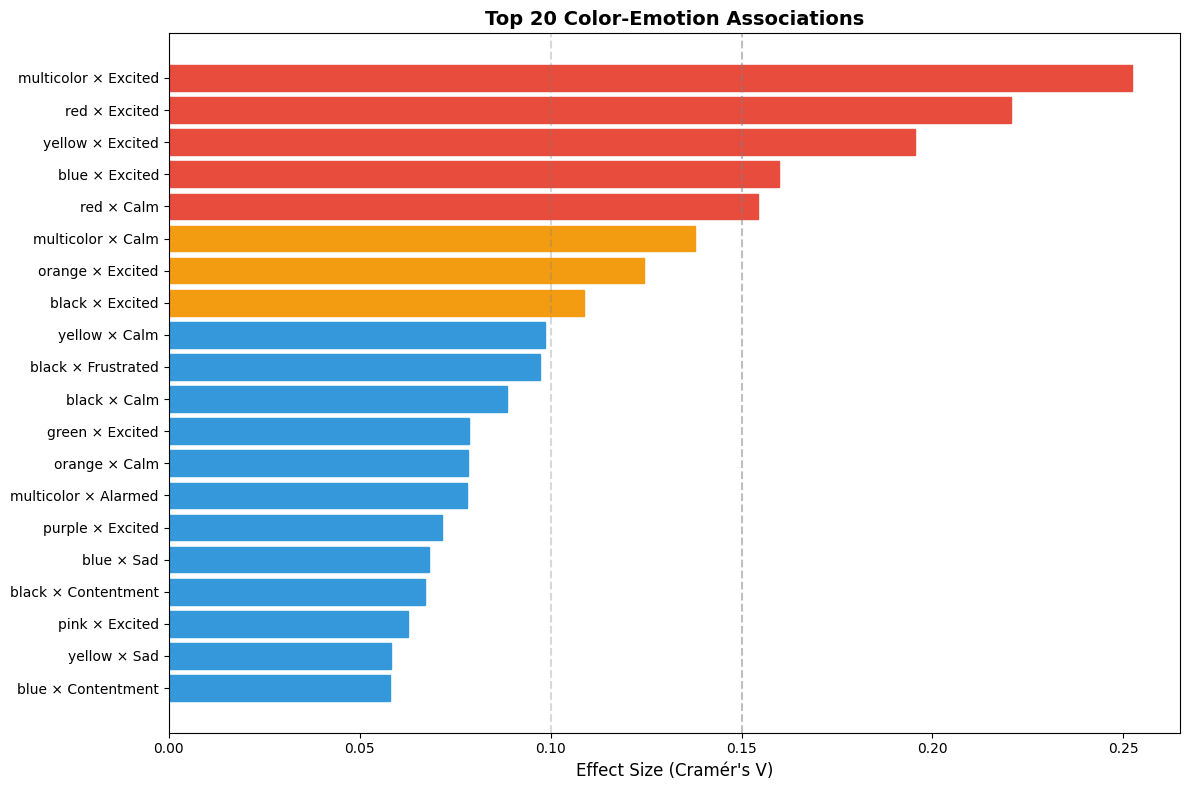

In [17]:
# ============================================================================
# CELL 6: VISUALIZATION
# ============================================================================
# Bar chart of top associations
fig, ax = plt.subplots(figsize=(12, 8))

top_n = min(20, len(sig_results))
plot_data = sig_results.head(top_n).copy()
plot_data['label'] = plot_data['color'] + ' × ' + plot_data['emotion']

bars = ax.barh(range(len(plot_data)), plot_data['cramers_v'])

# Color code by effect size
for i, (bar, cramers_v) in enumerate(zip(bars, plot_data['cramers_v'])):
    if cramers_v > 0.15:
        bar.set_color('#e74c3c')  # Strong - red
    elif cramers_v > 0.10:
        bar.set_color('#f39c12')  # Moderate - orange
    else:
        bar.set_color('#3498db')  # Weak - blue

ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data['label'])
ax.set_xlabel("Effect Size (Cramér's V)", fontsize=12)
ax.set_title("Top 20 Color-Emotion Associations", fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Reference lines
ax.axvline(x=0.10, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0.15, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================================
# CELL 7: SAVE RESULTS (IMPORTANT!)
# ============================================================================
# Save processed dataframe
eda_df.to_csv('emoart_5k_with_colors.csv', index=False)
print("✓ Processed dataframe saved to: emoart_5k_with_colors.csv")

# Save correlation results
sig_results.to_csv('color_emotion_correlations.csv', index=False)
print("✓ Correlation results saved to: color_emotion_correlations.csv")

# Save color term counts
color_counts = Counter([term for terms in eda_df['color_terms'] for term in terms])
color_counts_df = pd.DataFrame(color_counts.most_common(), columns=['color_term', 'count'])
color_counts_df.to_csv('color_term_frequencies.csv', index=False)
print("✓ Color term frequencies saved to: color_term_frequencies.csv")

✓ Processed dataframe saved to: emoart_5k_with_colors.csv
✓ Correlation results saved to: color_emotion_correlations.csv
✓ Color term frequencies saved to: color_term_frequencies.csv


In [18]:
print("First entry in the 'description' column:")
display(eda_df['description'].iloc[0])

First entry in the 'description' column:


{'first_section': {'description': 'The image features a playful arrangement of colored dots and abstract shapes scattered across a neutral background. The use of vibrant oranges, blues, and blacks offers a lively, rhythmic pattern that catches the eye.'},
 'second_section': {'emotional_impact': 'The combination of smooth brushstrokes, balanced colors, dynamic composition, and soft lighting evokes a cheerful, uplifting mood, promoting feelings of contentment and joy.',
  'visual_attributes': {'brushstroke': 'Smooth, blending seamlessly into the background.',
   'color': 'Warm and cool tones are used with moderate saturation, creating a harmonious contrast.',
   'composition': 'Dynamic and scattered, with no central focus, giving a sense of movement.',
   'light_and_shadow': 'Soft, even lighting with minimal contrast between light and dark areas.',
   'line_quality': 'The lines are smooth and defined, enhancing the playful feel.'}},
 'third_section': {'dominant_emotion': 'Calm',
  'emoti

In [20]:
# ============================================================================
# MULTIPLE TESTING CORRECTION
# ============================================================================
from scipy.stats import false_discovery_control

print("="*80)
print("MULTIPLE TESTING CORRECTION")
print("="*80)

# Original significant results
n_tests = len(results_df)
n_sig_original = len(sig_results)
expected_false_positives = n_tests * 0.05

print(f"Total tests performed: {n_tests}")
print(f"Significant at p<0.05: {n_sig_original}")
print(f"Expected false positives: {expected_false_positives:.1f}")

# Apply FDR correction (Benjamini-Hochberg)
results_df['p_adjusted_fdr'] = false_discovery_control(results_df['p_value'])

# Also calculate Bonferroni correction (more conservative)
results_df['p_adjusted_bonferroni'] = results_df['p_value'] * n_tests
results_df['p_adjusted_bonferroni'] = results_df['p_adjusted_bonferroni'].clip(upper=1.0)

# Filter with corrected p-values
sig_fdr = results_df[results_df['p_adjusted_fdr'] < 0.05].sort_values('cramers_v', ascending=False)
sig_bonferroni = results_df[results_df['p_adjusted_bonferroni'] < 0.05].sort_values('cramers_v', ascending=False)

print(f"\nAfter FDR correction: {len(sig_fdr)} significant")
print(f"After Bonferroni correction: {len(sig_bonferroni)} significant")

print("\nTop 10 associations surviving FDR correction:")
display_cols = ['color', 'emotion', 'cramers_v', 'p_value', 'p_adjusted_fdr']
print(sig_fdr.head(10)[display_cols].to_string(index=False))

MULTIPLE TESTING CORRECTION
Total tests performed: 144
Significant at p<0.05: 51
Expected false positives: 7.2

After FDR correction: 39 significant
After Bonferroni correction: 30 significant

Top 10 associations surviving FDR correction:
     color    emotion  cramers_v      p_value  p_adjusted_fdr
multicolor    Excited   0.252219 1.622477e-78    2.336367e-76
       red    Excited   0.220621 1.643232e-60    1.183127e-58
    yellow    Excited   0.195508 6.621234e-48    3.178192e-46
      blue    Excited   0.159755 1.464664e-32    5.272791e-31
       red       Calm   0.154193 1.899530e-30    5.470646e-29
multicolor       Calm   0.137884 1.118154e-24    2.683570e-23
    orange    Excited   0.124472 2.084233e-20    4.287565e-19
     black    Excited   0.108751 6.036280e-16    1.086530e-14
    yellow       Calm   0.098471 2.406260e-13    3.850017e-12
     black Frustrated   0.097298 4.595842e-13    6.618013e-12


In [22]:
# ============================================================================
# AROUSAL/VALENCE PATTERNS BY COLOR FAMILY
# ============================================================================

# Define color families
warm_colors = ['red', 'orange', 'yellow', 'pink']
cool_colors = ['blue', 'green', 'purple']
neutral_colors = ['brown', 'gray', 'black', 'white']

# Categorize each color
def categorize_color_family(color):
    if color in warm_colors:
        return 'Warm'
    elif color in cool_colors:
        return 'Cool'
    elif color in neutral_colors:
        return 'Neutral'
    else:
        return 'Other'

results_df['color_family'] = results_df['color'].apply(categorize_color_family)

# Merge with emotion metadata (arousal/valence)
# First, create emotion lookup from your df
emotion_metadata = eda_df[['dominant_emotion', 'arousal', 'valence']].drop_duplicates()

# Merge this into results
results_with_metadata = results_df.merge(
    emotion_metadata,
    left_on='emotion',
    right_on='dominant_emotion',
    how='left'
)

# Analyze patterns
print("="*80)
print("WARM VS COOL COLORS: AROUSAL PATTERNS")
print("="*80)

# Group by color family and arousal
arousal_pattern = results_with_metadata.groupby(['color_family', 'arousal']).agg({
    'cramers_v': 'mean',
    'significant': 'sum',
    'color': 'count'
}).round(3)

print("\nAverage effect size by color family and arousal:")
print(arousal_pattern)

# Statistical test: Are warm colors more associated with high arousal?
from scipy.stats import mannwhitneyu

warm_high_arousal = results_with_metadata[
    (results_with_metadata['color_family'] == 'Warm') &
    (results_with_metadata['arousal'] == 'High')
]['cramers_v']

cool_high_arousal = results_with_metadata[
    (results_with_metadata['color_family'] == 'Cool') &
    (results_with_metadata['arousal'] == 'High')
]['cramers_v']

if len(warm_high_arousal) > 0 and len(cool_high_arousal) > 0:
    stat, p_val = mannwhitneyu(warm_high_arousal, cool_high_arousal, alternative='greater')
    print(f"\nMann-Whitney U test: Warm colors have stronger high-arousal associations?")
    print(f"  U-statistic: {stat:.2f}, p-value: {p_val:.4f}")
    if p_val < 0.05:
        print("  ✓ Significant! Warm colors ARE more associated with high arousal")
    else:
        print("  ✗ Not significant")

WARM VS COOL COLORS: AROUSAL PATTERNS

Average effect size by color family and arousal:
                      cramers_v  significant  color
color_family arousal                               
Cool         High         0.030            7     18
             Low          0.017            6     21
Neutral      High         0.026            8     24
             Low          0.019            8     28
Other        High         0.074            4      6
             Low          0.034            2      7
Warm         High         0.038            9     24
             Low          0.024            8     28

Mann-Whitney U test: Warm colors have stronger high-arousal associations?
  U-statistic: 224.00, p-value: 0.4243
  ✗ Not significant


In [23]:
# ============================================================================
# COLOR VERSATILITY ANALYSIS
# ============================================================================

print("="*80)
print("COLOR VERSATILITY: Which colors associate with multiple emotions?")
print("="*80)

# Count significant associations per color
color_versatility = sig_fdr.groupby('color').agg({
    'emotion': lambda x: list(x),  # List of associated emotions
    'cramers_v': ['count', 'mean', 'max']
}).round(3)

color_versatility.columns = ['emotions_associated', 'n_associations', 'avg_effect_size', 'max_effect_size']

# Sort by number of associations
color_versatility = color_versatility.sort_values('n_associations', ascending=False)

print("\nColors by versatility (number of emotion associations):")
print(color_versatility)

# Question: Is multicolor the most versatile? Why?

COLOR VERSATILITY: Which colors associate with multiple emotions?

Colors by versatility (number of emotion associations):
                                          emotions_associated  n_associations  \
color                                                                           
multicolor   [Excited, Calm, Alarmed, Sad, Happy, Frustrated]               6   
black       [Excited, Frustrated, Calm, Contentment, Aroused]               5   
yellow              [Excited, Calm, Sad, Alarmed, Frustrated]               5   
blue         [Excited, Sad, Contentment, Alarmed, Frustrated]               5   
red                         [Excited, Calm, Sad, Contentment]               4   
brown                         [Excited, Alarmed, Contentment]               3   
green                                 [Excited, Sad, Alarmed]               3   
gray                                      [Calm, Contentment]               2   
pink                                         [Excited, Happy]      

In [25]:
# ============================================================================
# STYLE × EMOTION CONTINGENCY ANALYSIS
# ============================================================================
from scipy.stats import chi2_contingency

# Ensure 'art_style' and 'region' columns are present
# This code is duplicated from a previous cell to ensure execution order
print("Ensuring 'art_style' and 'region' columns are present...")
eda_df['art_style'] = eda_df['request_id'].apply(lambda x: x.split('_')[0].strip())
EASTERN_STYLES = ['China', 'Gongbi', 'Korea', 'Shin-hanga', 'Ink and wash painting', 'Ukiyo-e', 'Sōsaku hanga', 'Islamic', 'India']
eda_df['region'] = eda_df['art_style'].apply(lambda x: 'Eastern' if x in EASTERN_STYLES else 'Western')
print("✓ 'art_style' and 'region' columns checked/created.")


print("="*80)
print("STYLE-EMOTION ASSOCIATION ANALYSIS")
print("="*80)

# Create contingency table
style_emotion_table = pd.crosstab(eda_df['art_style'], eda_df['dominant_emotion'])

print(f"Contingency table shape: {style_emotion_table.shape}")
print(f"Styles: {style_emotion_table.shape[0]}, Emotions: {style_emotion_table.shape[1]}")

# Chi-square test for independence
chi2, p_value, dof, expected = chi2_contingency(style_emotion_table)

# Calculate Cramér's V
n = style_emotion_table.sum().sum()
min_dim = min(style_emotion_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"\nChi-square test of independence:")
print(f"  χ² = {chi2:.2f}")
print(f"  p-value = {p_value:.4e}")
print(f"  Cramér's V = {cramers_v:.4f}")

if p_value < 0.05:
    print("  ✓ Significant association between style and emotion!")
else:
    print("  ✗ No significant association")

Ensuring 'art_style' and 'region' columns are present...
✓ 'art_style' and 'region' columns checked/created.
STYLE-EMOTION ASSOCIATION ANALYSIS
Contingency table shape: (56, 12)
Styles: 56, Emotions: 12

Chi-square test of independence:
  χ² = 2606.36
  p-value = 1.3181e-245
  Cramér's V = 0.2070
  ✓ Significant association between style and emotion!


In [26]:
# ============================================================================
# EMOTION PROFILES BY STYLE
# ============================================================================

# Calculate emotion distribution for each style
style_profiles = pd.crosstab(eda_df['art_style'], eda_df['dominant_emotion'], normalize='index') * 100

# Find styles with most distinctive emotion profiles
print("\nStyles with highest 'Calm' percentage:")
print(style_profiles.nlargest(10, 'Calm')[['Calm', 'Excited', 'Sad']].round(1))

print("\nStyles with highest 'Excited' percentage:")
print(style_profiles.nlargest(10, 'Excited')[['Calm', 'Excited', 'Sad']].round(1))

# Calculate diversity (entropy) for each style
from scipy.stats import entropy

style_profiles['entropy'] = style_profiles.apply(
    lambda row: entropy(row / 100), axis=1  # Normalize to probabilities
)

print("\nEmotion diversity by style:")
print(style_profiles[['entropy']].sort_values('entropy', ascending=False).round(3))


Styles with highest 'Calm' percentage:
dominant_emotion       Calm  Excited  Sad
art_style                                
China                  96.0      0.0  0.0
Gongbi                 87.5      0.0  0.0
Korea                  87.0      1.0  0.0
Shin-hanga             84.0      1.0  0.0
Ink and wash painting  78.0      8.0  3.0
Early Renaissance      74.0      7.0  9.0
Impressionism          73.0      7.0  1.0
High Renaissance       72.0      7.0  7.0
Contemporary Realism   70.0     10.0  9.0
Ukiyo-e                70.0      7.0  0.0

Styles with highest 'Excited' percentage:
dominant_emotion        Calm  Excited  Sad
art_style                                 
Neo-Pop Art             25.0     62.0  0.0
Fauvism                 27.0     56.0  1.0
Abstract Expressionism  33.0     52.0  1.0
Tachisme                21.0     52.0  4.0
Lyrical Abstraction     36.0     51.0  2.0
Pop Art                 33.0     46.0  3.0
Op Art                  42.0     45.0  0.0
Hard Edge Painting      49

In [27]:
# ============================================================================
# STRATIFIED COLOR-EMOTION ANALYSIS BY REGION
# ============================================================================

print("="*80)
print("COLOR-EMOTION ASSOCIATIONS: EASTERN VS WESTERN")
print("="*80)

# Define regions (you already have this)
eastern_df = eda_df[eda_df['region'] == 'Eastern']
western_df = eda_df[eda_df['region'] == 'Western']

print(f"Eastern samples: {len(eastern_df)}")
print(f"Western samples: {len(western_df)}")

# Run color analysis for each region
def analyze_region_colors(region_df, region_name):
    """Run color-emotion analysis for a specific region"""
    results = []

    for color in color_lexicon_expanded.keys():
        color_count = region_df[f'has_{color}'].sum()

        if color_count < 20:  # Need at least 20 for regional analysis
            continue

        for emotion in region_df['dominant_emotion'].dropna().unique():
            has_color = region_df[f'has_{color}']
            has_emotion = region_df['dominant_emotion'] == emotion

            contingency = pd.crosstab(has_color, has_emotion)

            if contingency.shape != (2, 2):
                continue

            chi2, p_value, dof, expected = chi2_contingency(contingency)
            n = contingency.sum().sum()
            cramers_v = np.sqrt(chi2 / n)

            n_both = contingency.loc[True, True] if (True in contingency.index and True in contingency.columns) else 0

            results.append({
                'region': region_name,
                'color': color,
                'emotion': emotion,
                'cramers_v': cramers_v,
                'p_value': p_value,
                'n_both': n_both,
                'significant': p_value < 0.05
            })

    return pd.DataFrame(results)

# Analyze each region
eastern_results = analyze_region_colors(eastern_df, 'Eastern')
western_results = analyze_region_colors(western_df, 'Western')

# Compare top associations
eastern_sig = eastern_results[eastern_results['significant']].sort_values('cramers_v', ascending=False)
western_sig = western_results[western_results['significant']].sort_values('cramers_v', ascending=False)

print("\nTop 10 Eastern color-emotion associations:")
if len(eastern_sig) > 0:
    print(eastern_sig.head(10)[['color', 'emotion', 'cramers_v', 'p_value']].to_string(index=False))
else:
    print("No significant associations found (likely due to low diversity)")

print("\nTop 10 Western color-emotion associations:")
print(western_sig.head(10)[['color', 'emotion', 'cramers_v', 'p_value']].to_string(index=False))

# Compare specific color across regions
print("\n" + "="*80)
print("CROSS-REGIONAL COMPARISON: Does 'red' mean different things?")
print("="*80)

for color in ['red', 'blue', 'black', 'multicolor']:
    eastern_color = eastern_sig[eastern_sig['color'] == color]
    western_color = western_sig[western_sig['color'] == color]

    print(f"\n{color.upper()}:")
    print(f"  Eastern associations: {list(eastern_color['emotion'].values)}")
    print(f"  Western associations: {list(western_color['emotion'].values)}")

COLOR-EMOTION ASSOCIATIONS: EASTERN VS WESTERN
Eastern samples: 832
Western samples: 4700

Top 10 Eastern color-emotion associations:
     color     emotion  cramers_v      p_value
multicolor     Excited   0.219962 2.228859e-10
multicolor        Calm   0.204102 3.928108e-09
    yellow        Calm   0.083290 1.628582e-02
       red     Annoyed   0.082408 1.745378e-02
multicolor Contentment   0.068574 4.793076e-02

Top 10 Western color-emotion associations:
     color    emotion  cramers_v      p_value
multicolor    Excited   0.253975 6.730144e-68
       red    Excited   0.228696 2.117395e-55
    yellow    Excited   0.199456 1.451319e-42
      blue    Excited   0.164318 1.951480e-29
       red       Calm   0.157427 3.729394e-27
    orange    Excited   0.123924 1.965416e-17
multicolor       Calm   0.119482 2.584733e-16
     black    Excited   0.109836 5.074766e-14
     black Frustrated   0.098190 1.678786e-11
multicolor    Alarmed   0.089698 7.779165e-10

CROSS-REGIONAL COMPARISON: Does '

In [28]:
# ============================================================================
# COMPREHENSIVE REGIONAL COMPARISON TABLE
# ============================================================================

print("="*80)
print("REGIONAL COLOR-EMOTION PATTERN COMPARISON")
print("="*80)

comparison_data = []

for color in ['red', 'blue', 'black', 'yellow', 'multicolor']:
    eastern_count = len(eastern_sig[eastern_sig['color'] == color])
    western_count = len(western_sig[western_sig['color'] == color])

    eastern_emotions = list(eastern_sig[eastern_sig['color'] == color]['emotion'].values)
    western_emotions = list(western_sig[western_sig['color'] == color]['emotion'].values)

    # Get max effect size for each
    eastern_max_v = eastern_sig[eastern_sig['color'] == color]['cramers_v'].max() if eastern_count > 0 else 0
    western_max_v = western_sig[western_sig['color'] == color]['cramers_v'].max() if western_count > 0 else 0

    comparison_data.append({
        'Color': color,
        'Eastern_N_Assoc': eastern_count,
        'Western_N_Assoc': western_count,
        'Eastern_Max_V': f"{eastern_max_v:.3f}",
        'Western_Max_V': f"{western_max_v:.3f}",
        'Eastern_Emotions': ', '.join(eastern_emotions) if eastern_emotions else 'None',
        'Western_Emotions': ', '.join(western_emotions[:3]) + '...' if len(western_emotions) > 3 else ', '.join(western_emotions)
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Calculate diversity metrics
print("\n" + "="*80)
print("COLOR-EMOTION DIVERSITY BY REGION")
print("="*80)

eastern_total_assoc = len(eastern_sig)
western_total_assoc = len(western_sig)

eastern_unique_colors = eastern_sig['color'].nunique()
western_unique_colors = western_sig['color'].nunique()

print(f"Total significant associations:")
print(f"  Eastern: {eastern_total_assoc}")
print(f"  Western: {western_total_assoc}")
print(f"\nUnique colors with associations:")
print(f"  Eastern: {eastern_unique_colors} / {len(color_lexicon_expanded)}")
print(f"  Western: {western_unique_colors} / {len(color_lexicon_expanded)}")
print(f"\nAverage associations per color:")
print(f"  Eastern: {eastern_total_assoc / eastern_unique_colors:.1f}" if eastern_unique_colors > 0 else "  Eastern: 0")
print(f"  Western: {western_total_assoc / western_unique_colors:.1f}")

REGIONAL COLOR-EMOTION PATTERN COMPARISON
     Color  Eastern_N_Assoc  Western_N_Assoc Eastern_Max_V Western_Max_V           Eastern_Emotions             Western_Emotions
       red                1                4         0.082         0.229                    Annoyed        Excited, Calm, Sad...
      blue                0                5         0.000         0.164                       None Excited, Sad, Contentment...
     black                0                5         0.000         0.110                       None Excited, Frustrated, Calm...
    yellow                1                5         0.083         0.199                       Calm        Excited, Calm, Sad...
multicolor                3                7         0.220         0.254 Excited, Calm, Contentment    Excited, Calm, Alarmed...

COLOR-EMOTION DIVERSITY BY REGION
Total significant associations:
  Eastern: 5
  Western: 51

Unique colors with associations:
  Eastern: 3 / 12
  Western: 12 / 12

Average associatio

In [29]:
# Focus on styles with enough samples
eastern_styles_to_test = ['China', 'Ukiyo-e', 'Ink and wash painting']

for style in eastern_styles_to_test:
    style_df = eda_df[eda_df['art_style'] == style]
    print(f"\n{style} (n={len(style_df)}):")
    print(f"Emotion distribution: {style_df['dominant_emotion'].value_counts().to_dict()}")

    # If there's ANY variance, test color patterns
    if style_df['dominant_emotion'].nunique() > 1: # Corrected from > 2 to > 1 to test any variance
        # Run color-emotion analysis for this style
        # This part is commented out, you would need to uncomment and adapt
        # the analyze_color_emotion_correlations function for a single style if needed.
        pass


China (n=100):
Emotion distribution: {'Calm': 96, 'Contentment': 4}

Ukiyo-e (n=100):
Emotion distribution: {'Calm': 70, 'Contentment': 18, 'Excited': 7, 'Frustrated': 3, 'Alarmed': 1, 'Annoyed': 1}

Ink and wash painting (n=100):
Emotion distribution: {'Calm': 78, 'Excited': 8, 'Contentment': 8, 'Sad': 3, 'Alarmed': 2, 'Frustrated': 1}


In [30]:
# Sample "Calm" Eastern artworks with color terms
eastern_calm_with_colors = eastern_df[
    (eastern_df['dominant_emotion'] == 'Calm') &
    (eastern_df['color_terms'].apply(len) > 0)
].sample(20)

# For each, examine:
# 1. Does the description suggest calmness?
# 2. What's the actual subject matter?
# 3. Are there visual indicators of other emotions (movement, tension, drama)?

print("Analyzing sampled 'Calm' Eastern artworks with color terms:")

for index, row in eastern_calm_with_colors.iterrows():
    print("-" * 50)
    print(f"Artwork ID: {row['request_id']}")
    print(f"Image Path: {row['image_path']}")
    print(f"Dominant Emotion: {row['dominant_emotion']}")
    print(f"Arousal: {row['arousal']}")
    print(f"Valence: {row['valence']}")
    print(f"Color Terms: {row['color_terms']}")
    print(f"Description: {row['description_text'][:500]}...") # Print first 500 characters of the extracted text

    # Note: To analyze subject matter and visual indicators further,
    # you would typically need to view the images themselves, which is
    # not possible directly in this text-based output.
    # The description and image path provide clues.

Analyzing sampled 'Calm' Eastern artworks with color terms:
--------------------------------------------------
Artwork ID: China_images_request-40
Image Path: Images\China_images\FS-7458_17.jpg
Dominant Emotion: Calm
Arousal: Low
Valence: Positive
Color Terms: ['earthy', 'muted']
Description: This artwork portrays a serene, natural scene with delicate plants and two birds in flight. The background is a muted, earthy tone, allowing the subtle details of the flora and fauna to come forward gently....
--------------------------------------------------
Artwork ID: Korea_request-98
Image Path: Images\Korea\duk001101-000-80001.jpg
Dominant Emotion: Calm
Arousal: Low
Valence: Positive
Color Terms: ['pink']
Description: A delicate painting showcases a butterfly perched on blooming pink peonies. The floral arrangement is detailed with subtle, graceful leaves, set against a textured background, creating an elegant and tranquil scene....
--------------------------------------------------
Artwork 

In [31]:
import ast
import pandas as pd

def extract_visual_attributes(description_entry):
    """
    Safely extract specific visual attributes from a description entry.
    """
    attributes = {
        'brushstroke': None,
        'composition': None,
        'color_attribute': None,
        'light_and_shadow': None,
        'line_quality': None
    }

    # Handle None or NaN first
    if pd.isna(description_entry):
        return attributes

    # Handle dictionary format
    if isinstance(description_entry, dict):
        try:
            # Check for 'second_section' key
            if 'second_section' in description_entry and isinstance(description_entry['second_section'], dict):
                second_section = description_entry['second_section']
                # Check for 'visual_attributes' key
                if 'visual_attributes' in second_section and isinstance(second_section['visual_attributes'], dict):
                    visual_attributes = second_section['visual_attributes']
                    # Extract each attribute safely
                    attributes['brushstroke'] = visual_attributes.get('brushstroke')
                    attributes['composition'] = visual_attributes.get('composition')
                    attributes['color_attribute'] = visual_attributes.get('color') # Note: key is 'color'
                    attributes['light_and_shadow'] = visual_attributes.get('light_and_shadow')
                    attributes['line_quality'] = visual_attributes.get('line_quality')
                    # Return attributes once found
                    return attributes
        except Exception as e:
            print(f"Debug: Error processing dictionary: {e}, Value: {description_entry}")
            # If there's an error during dictionary processing, return attributes with Nones
            return {attr: None for attr in attributes.keys()}

    # Handle string format that might represent a dictionary
    if isinstance(description_entry, str):
        try:
            # Attempt to safely evaluate the string as a dictionary
            parsed_dict = ast.literal_eval(description_entry)
            # If successful, process it as a dictionary
            if isinstance(parsed_dict, dict):
                 try:
                    if 'second_section' in parsed_dict and isinstance(parsed_dict['second_section'], dict):
                        second_section = parsed_dict['second_section']
                        if 'visual_attributes' in second_section and isinstance(second_section['visual_attributes'], dict):
                            visual_attributes = second_section['visual_attributes']
                            attributes['brushstroke'] = visual_attributes.get('brushstroke')
                            attributes['composition'] = visual_attributes.get('composition')
                            attributes['color_attribute'] = visual_attributes.get('color')
                            attributes['light_and_shadow'] = visual_attributes.get('light_and_shadow')
                            attributes['line_quality'] = visual_attributes.get('line_quality')
                            return attributes
                 except Exception as e:
                     print(f"Debug: Error processing parsed string as dictionary: {e}")
                     return {attr: None for attr in attributes.keys()}
            # If string parsing didn't yield a dictionary with the expected structure,
            # treat the string itself if you want to try extracting from plain text
            # Currently returning Nones if not matching expected dict structure
            return {attr: None for attr in attributes.keys()} # Return Nones if not expected dictionary structure
        except (ValueError, SyntaxError) as e:
             # If string is not a valid dictionary representation, return Nones
             print(f"Debug: Error parsing string as dict: {e}, Value: {description_entry[:100]}...")
             return {attr: None for attr in attributes.keys()}


    # Handle integers, floats, or other non-text types
    if isinstance(description_entry, (int, float, bool)):
         print(f"Debug: Encountered non-string/dict type: {type(description_entry).__name__}, Value: {description_entry}")
         return {attr: None for attr in attributes.keys()}


    # For any other unhandled type or if expected keys/structure not found, return Nones
    print(f"Debug: Encountered unhandled or unexpected structure type: {type(description_entry).__name__}, Value: {description_entry}")
    return {attr: None for attr in attributes.keys()}


# Apply the function to the 'description' column and create new columns
visual_attributes_df = eda_df['description'].apply(extract_visual_attributes).apply(pd.Series)

# Rename 'color' column to 'color_attribute' for clarity (already handled in function but good practice)
# Check if 'color' column exists before renaming
if 'color' in visual_attributes_df.columns:
    visual_attributes_df = visual_attributes_df.rename(columns={'color': 'color_attribute'})
else:
    # If 'color' wasn't extracted, ensure 'color_attribute' column exists with None values
    if 'color_attribute' not in visual_attributes_df.columns:
         visual_attributes_df['color_attribute'] = None


# Concatenate the new columns to the main dataframe
# Check if columns exist before concatenating to avoid duplicates if cell is run multiple times
new_columns = ['brushstroke', 'composition', 'color_attribute', 'light_and_shadow', 'line_quality']
for col in new_columns:
    if col in eda_df.columns:
        eda_df = eda_df.drop(columns=[col])

eda_df = pd.concat([eda_df, visual_attributes_df], axis=1)


# Display the updated dataframe with the new columns
print("DataFrame with extracted visual attributes:")
display(eda_df.head())

# Check value counts for one of the new columns
print("\nValue counts for 'composition':")
display(eda_df['composition'].value_counts().head(10))

print("\nValue counts for 'color_attribute':")
display(eda_df['color_attribute'].value_counts().head(10))

print("\nValue counts for 'brushstroke':")
display(eda_df['brushstroke'].value_counts().head(10))

print("\nValue counts for 'light_and_shadow':")
display(eda_df['light_and_shadow'].value_counts().head(10))

print("\nValue counts for 'line_quality':")
display(eda_df['line_quality'].value_counts().head(10))

DataFrame with extracted visual attributes:


,request_id,image_path,description,dominant_emotion,arousal,valence,healing_effects,description_text,color_terms,color_categories,...,has_black,has_gray,has_multicolor,art_style,region,brushstroke,composition,color_attribute,light_and_shadow,line_quality
0,Abstract Art_request-1,Images\Abstract Art\0006080_YuriZlotnikov-Sign...,{'first_section': {'description': 'The image f...,Calm,Low,Positive,"[Relieve Stress, Embrace Joy]",The image features a playful arrangement of co...,"[blues, vibrant]","[blue, multicolor]",...,False,False,True,Abstract Art,Western,"Smooth, blending seamlessly into the background.","Dynamic and scattered, with no central focus, ...",Warm and cool tones are used with moderate sat...,"Soft, even lighting with minimal contrast betw...","The lines are smooth and defined, enhancing th..."
1,Abstract Art_request-2,Images\Abstract Art\0006185_PaulKlee-GlassFaca...,{'first_section': {'description': 'The artwork...,Excited,High,Positive,"[Gain Inspiration, Embrace Joy]","The artwork features a grid of vibrant, geomet...","[red, orange, green, blue, black, colors, vibr...","[green, orange, blue, red, multicolor, black]",...,True,False,True,Abstract Art,Western,"Fine and precise, creating defined edges betwe...","Dynamic with an irregular grid, providing bala...",Warm and cool tones intermingle; moderately sa...,"Minimal shadowing, focused on flat color appli...","Thick and bold, creating a stark separation be..."
2,Abstract Art_request-3,Images\Abstract Art\0006313_WilliBaumeister-Pl...,{'first_section': {'description': 'The image f...,Calm,Low,Positive,"[Relieve Stress, Gain Inspiration]",The image features an abstract geometric compo...,[soft],[multicolor],...,False,False,True,Abstract Art,Western,"The brushwork is smooth and even, emphasizing ...","The arrangement is dynamic, with a central foc...",The palette includes warm and cool tones with ...,"There is minimal light and shadow, with flat c...","Lines are predominantly hard and smooth, contr..."
3,Abstract Art_request-4,Images\Abstract Art\0006400_OttoFreundlich-Kom...,{'first_section': {'description': 'The image f...,Excited,High,Positive,"[Gain Inspiration, Embrace Joy]",The image features dynamic abstract forms in b...,"[black, bold, pale]","[multicolor, black]",...,True,False,True,Abstract Art,Western,"Fine and precise, emphasizing sharp edges and ...",Asymmetrical with a dynamic flow; elements gui...,Dominantly cool tones with stark black and mut...,"High contrast of black against light, enhancin...","Both thick and fine lines, with smooth, delibe..."
4,Abstract Art_request-5,Images\Abstract Art\0006526_AlexejvonJawlensky...,{'first_section': {'description': 'The paintin...,Calm,Low,Positive,"[Relieve Stress, Find Hope]",The painting features an array of abstract sha...,"[colors, vibrant]",[multicolor],...,False,False,True,Abstract Art,Western,"Smooth and subtle, blending seamlessly to form...","Dynamic, with a scattering of shapes that guid...","A mix of cool and warm tones, with moderate sa...",Subtle light sources diffuse across the canvas...,"Soft and flowing, yet defined, giving each sha..."



Value counts for 'composition':


,count
composition,
Central focus with symmetrical balance.,6
"Central focus with a balanced, harmonious arrangement.",3
"Dynamic and asymmetrical, guiding the eye across the canvas.",3
Central focus with dynamic elements.,3
"Central focus with balanced symmetry, drawing attention to the subject's face.",2
"The composition is dynamic yet balanced, with boats leading the eye across the canvas.",2
"The composition is dynamic, guiding the viewer's eye across various focal points.",2
"The composition is dynamic, with a sense of flowing movement across the canvas.",2
Central focus with a symmetrical balance.,2



Value counts for 'color_attribute':


...

,count
brushstroke,
Smooth,9
"Fine and delicate, enhancing intricate details.",7
"Fine and precise, capturing intricate details.",7
"Fine and delicate, capturing intricate details.",7
"Fine and delicate, emphasizing intricate details.",5
"Rough, expressive strokes.",4
"Rough and expressive, adding texture and depth.",4
"Smooth, uniform application.",4
"Fine and precise, emphasizing detail.",3



Value counts for 'light_and_shadow':


,count
light_and_shadow,
Soft lighting with gentle contrasts.,3
"Soft light source, gentle light-dark contrast.",3
"Soft light source, subtle light-dark contrast, enhancing serenity.",2
Soft light source with gentle contrast.,2
"Soft light, subtle contrast",2
"Soft lighting highlights the face, with gentle shadows adding depth and dimension.",2
"Soft light, creating a gentle contrast.",2
"Soft lighting with gentle shadows, creating depth and dimension.",2
"Soft lighting with gentle contrasts, enhancing the dreamlike quality.",2



Value counts for 'line_quality':


,count
line_quality,
"Thin, smooth, and continuous.",2
"Soft and smooth, guiding the eye gently across the scene.",2
"Thin, smooth lines convey grace and elegance.",2
"The lines are firm and defined, framing the structures against the softer sky.",1
"The lines vary from thick to thin, with a mix of smooth and broken qualities that impart energy and emotion.",1
"Lines are fluid and harmonious, blending seamlessly into the scene, enhancing the painting's graceful quality.",1
"Lines are smooth and flowing, with a mix of hard and soft edges.",1
"Lines in the portrait are soft and natural, with delicate transitions from light to dark.",1
"Broken, vigorous lines suggest motion and ruggedness in the depiction.",1


In [32]:
# ============================================================================
# STEP 1: Extract Art Style and Region
# ============================================================================

print("Extracting 'art_style' from 'request_id'...")
eda_df['art_style'] = eda_df['request_id'].apply(lambda x: x.split('_')[0].strip())
print("✓ 'art_style' column created.")

# Define Eastern styles based on your dataset knowledge or previous mentions
# (Adjust this list if your dataset has different style names for Eastern art)
EASTERN_STYLES = [
    'China', 'Gongbi', 'Korea', 'Shin-hanga', 'Ink and wash painting', 'Ukiyo-e', 'Sōsaku hanga',
    'Islamic', 'India'
]

print("Assigning 'region' based on 'art_style'...")
eda_df['region'] = eda_df['art_style'].apply(lambda x: 'Eastern' if x in EASTERN_STYLES else 'Western')
print("✓ 'region' column created.")

print("\nUpdated `eda_df` head with new columns:")
display(eda_df[['request_id', 'art_style', 'region', 'dominant_emotion']].head())

Extracting 'art_style' from 'request_id'...
✓ 'art_style' column created.
Assigning 'region' based on 'art_style'...
✓ 'region' column created.

Updated `eda_df` head with new columns:


,request_id,art_style,region,dominant_emotion
0,Abstract Art_request-1,Abstract Art,Western,Calm
1,Abstract Art_request-2,Abstract Art,Western,Excited
2,Abstract Art_request-3,Abstract Art,Western,Calm
3,Abstract Art_request-4,Abstract Art,Western,Excited
4,Abstract Art_request-5,Abstract Art,Western,Calm


# SECTION 2